# Pattern pre-processing

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import rescale_intensity
from matplotlib.colors import LogNorm
from IPython.display import display
from ipywidgets import Dropdown, interactive, Layout, FloatSlider

plt.rcParams['figure.dpi'] = 150

In [2]:
folder_data = './data/'
s = np.load(folder_data+'selected_patterns.npy')
tmds = np.load(folder_data+'selected_patterns_tmds.npy')
names = ['Al', r'$\theta^{\prime}_{001}$', r'$\theta^{\prime}_{100-1}$', r'$\theta^{\prime}_{100-2}$', r'T$_{1-1}$', r'T$_{1-2}$']

In [3]:
def threshold_and_rescale(s, th, disk_r):
    # Threshold the patterns and set all intensities below the threshold to zero
    sts = s.copy()
    sts[sts < th] = 0.
    
    # Rescale intensity and change dtype
    smax, smin = np.max(sts), np.min(sts)
    sts = np.array(list(map(lambda x: rescale_intensity(x, in_range=(smin, smax), out_range=(0, 255)), sts)), dtype=np.uint8)

    return sts

In [4]:
i = 8
disk_rs = np.arange(1, 5.25, 0.25)
dr = disk_rs[i]
tmds_i = tmds[i]

th = 0.3
sts = threshold_and_rescale(tmds_i, th, dr)

interactive(children=(Dropdown(description='disk radius:', index=8, layout=Layout(width='200px'), options=(np.…

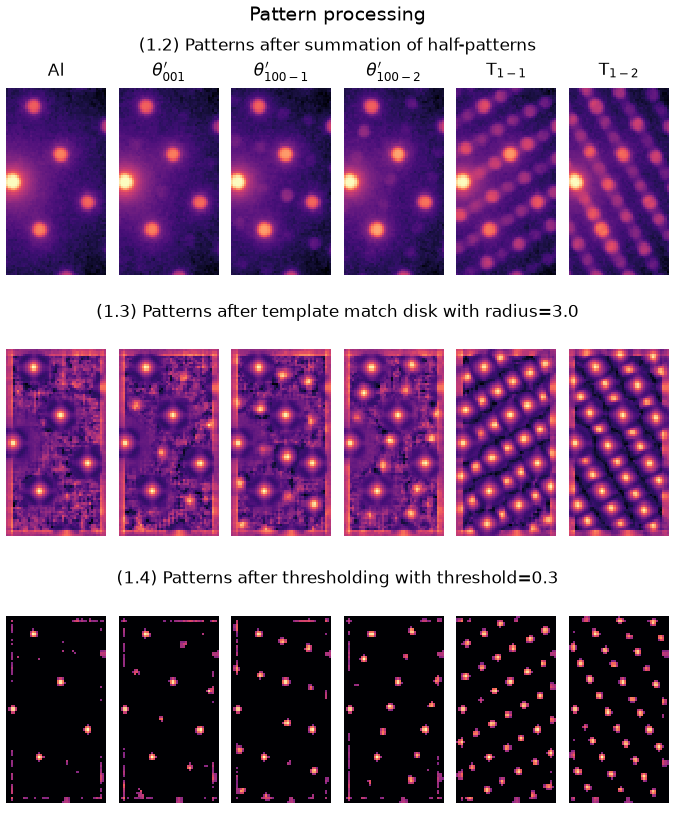

In [5]:
# | label: app:preprocessing_widget
fig = plt.figure(layout='constrained', figsize=(4.5, 5.5))

subfigs = fig.subfigures(3, 1, wspace=0.0, height_ratios=[1, 1, 1])
fig.suptitle('Pattern processing', fontsize=9)

cmap_p = 'magma'

axs = subfigs[0].subplots(1, 6)
p_axs = []
for ax, p, n in zip(axs, s, names):
    ax.axis('off')
    p_axs.append(ax.imshow(p, cmap=cmap_p, interpolation='none', norm=LogNorm(vmin=p.min(), vmax=p.max())))
    ax.set_title(n, fontsize=8)
subfigs[0].suptitle('(1.2) Patterns after summation of half-patterns', fontsize=8)

axs1 = subfigs[1].subplots(1, 6)
t_axs = []
for ax1, t in zip(axs1, tmds_i):
    ax1.axis('off')
    t_axs.append(ax1.imshow(t, cmap=cmap_p, interpolation='none'))
subfigs[1].suptitle('(1.3) Patterns after template match disk with radius=' + str(dr), fontsize=8)

axs2 = subfigs[2].subplots(1, 6)
s_axs = []
for ax2, st in zip(axs2, sts):
    ax2.axis('off')
    s_axs.append(ax2.imshow(st, cmap=cmap_p, interpolation='none'))
subfigs[2].suptitle('(1.4) Patterns after thresholding with threshold=' + str(round(th, 2)), fontsize=8)

fig.canvas.resizable = False
fig.canvas.header_visible = False
fig.canvas.footer_visible = False
fig.canvas.toolbar_visible = True
fig.canvas.toolbar_position = 'top'


def update_plots(dr, th):
    i = int(np.where(disk_rs == dr)[0][0])
    tmds_i = tmds[i]
    for t_ax, t in zip(t_axs, tmds_i):
        t_ax.set_data(t)
        t_ax.set_clim([np.min(t), np.max(t)])
    subfigs[1].suptitle('(1.3) Patterns after template match disk with radius=' + str(dr), fontsize=8)
    
    sts = threshold_and_rescale(tmds_i, th, dr)
    for s_ax, st in zip(s_axs, sts):
        disk_r = int(dr)
        s_ax.set_data(st.data)
        s_ax.set_clim([np.min(st), np.max(st)])
    subfigs[2].suptitle('(1.4) Patterns after thresholding with threshold=' + str(round(th, 2)), fontsize=8)
    fig.canvas.draw_idle()

    return None


disk_r_widget = Dropdown(options=disk_rs, index=i, description='disk radius:', 
                         layout=Layout(width='200px'), style={'description_width': '100px'}, disabled=False)
th_slider = FloatSlider(value=th, min=-0.9, max=0.9, step=0.05, description='threshold: ', continuous_update=True, 
                        layout=Layout(width='350px'), style={'description_width': '100px'}, disabled=False)
wid = interactive(update_plots, dr=disk_r_widget, th=th_slider)
display(wid)